# Imports

In [1]:
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from natsort import natsort_keygen, natsorted
import matplotlib.font_manager as fm
from sklearn import preprocessing
import matplotlib.pyplot as plt
from pygam import LinearGAM
from skimage import io
import seaborn as sns
import pandas as pd
import numpy as np
import anndata
import cv2

from Functions import save_adata, save_fig

# User input

In [2]:
load_dir = "/tachyon/scratch/gatmc/Users/kahnmaur/1_Projects/08_NVS-DARe-SGO/1_Experiments/08-04_MinimalMedia/2_Results/3_QC.h5ad"
#Replace lowers if not following standard folder structure
save_dir = load_dir.replace(load_dir.split("/")[-1],"")
plot_save_dir = save_dir.replace("2_Results","3_Plots")

fig_param = {"axes.spines.right": False,
                  "axes.spines.top": False,
                  "axes.spines.left": True,
                  "axes.spines.bottom": True,
                  "pdf.fonttype": 42,
                  "font.size": 6,
                  "axes.labelsize": 6,
                  "axes.titlesize": 8,
                  "xtick.labelsize": 6,
                  "ytick.labelsize": 6,
                  "legend.fontsize": 6}

sns.set_theme(rc = fig_param, style = "ticks")

# Load & misc

In [3]:
ad = anndata.read_h5ad(load_dir)


In [4]:
palette1 =  {"DAM":'#adb5bd',
            "GEM-Rspo1":"#e9ecef",
            "GEM-WNT-NGS":"#dee2e6",
            "GEM-NRG1":"#adb5bd",
            "GEM-NAC":"#495057",
            "GEM-A83":'xkcd:fresh green', 
            "GEM-IGF1":'xkcd:seaweed',
            "GEM-FGF2":'xkcd:blue green',
            "GEM-Nog.":"xkcd:seaweed", 
            "Jeon":'#48cae4',
            "DAM-EGF":'xkcd:dark sky blue',
            "DAM-NRG1":'xkcd:fresh green',
            "DAM-Rspo1":'xkcd:seaweed',
            "DAM-Noggin":'xkcd:blue green',
            "DAM-IGF1":'#fffcf2', 
            "DAM-FGF2":'#faedcd',
            "DAM-VitA":'#ffddd2',
            "Jeon-Half":'#90e0ef',
            "Jeon-Full":'#48cae4'}

# Plots

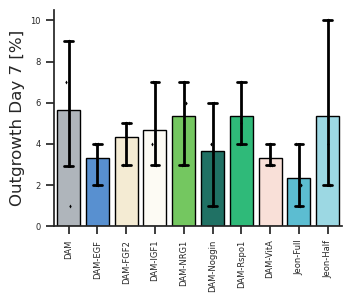

In [17]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3.5,3))

df = ad.uns["Outgrowth_DF"]
df = df[df.Other == "D7"]
ax1 = sns.barplot(
            ax = ax,
            data = df,
            x = "Medium",
            hue = "Medium",
            y = round(df.Organoid_No/2.50),
            capsize = .3,
            err_kws= {'linewidth': 2, "color": "black"},
            #order = ["Ctrl", "Gefitinib", "Lumretuzumab", "LY294002"],
            palette = palette1,
            linewidth = 1,
            edgecolor = "Black",
            legend = False
           )

sns.stripplot(
            ax = ax,
            data = df,
            x = "Medium",
            y = round(df.Organoid_No/2.50),
            size = 2,
            marker = "d",
            color = "black",

            #order = ["Ctrl", "Gefitinib", "Lumretuzumab", "LY294002"]
             )



# for patch in [2,4,5]:
#     ax1.patches[patch].set_hatch("//")
#     ax1.patches[patch].set_edgecolor("black")
ax.set_xlabel('', fontsize = 22)
ax.set_ylabel("Outgrowth Day 7 [%]", fontsize = 12)

plt.xticks(rotation=90)

plt.tight_layout()

save_images = 0

if save_images == 1:
    save_fig(fig, plot_save_dir, "6Plot_Outgrowth_EB")

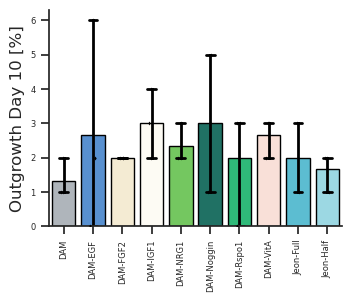

In [35]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3.5,3))

df = ad.uns["Outgrowth_DF"]
df = df[df.Other == "D10"]
ax1 = sns.barplot(
            ax = ax,
            data = df,
            x = "Medium",
            hue = "Medium",
            y = round(df.Organoid_No/2.50),
            capsize = .3,
            err_kws= {'linewidth': 2, "color": "black"},
            #order = ["Ctrl", "Gefitinib", "Lumretuzumab", "LY294002"],
            palette = palette1,
            linewidth = 1,
            edgecolor = "Black",
            legend = False
           )

sns.stripplot(
            ax = ax,
            data = df,
            x = "Medium",
            y = round(df.Organoid_No/2.50),
            size = 2,
            marker = "d",
            color = "black",

            #order = ["Ctrl", "Gefitinib", "Lumretuzumab", "LY294002"]
             )



# for patch in [2,4,5]:
#     ax1.patches[patch].set_hatch("//")
#     ax1.patches[patch].set_edgecolor("black")
ax.set_xlabel('', fontsize = 22)
ax.set_ylabel("Outgrowth Day 10 [%]", fontsize = 12)

plt.xticks(rotation=90)

plt.tight_layout()

save_images = 0

if save_images == 1:
    save_fig(fig, plot_save_dir, "6Plot_Outgrowth_EB")

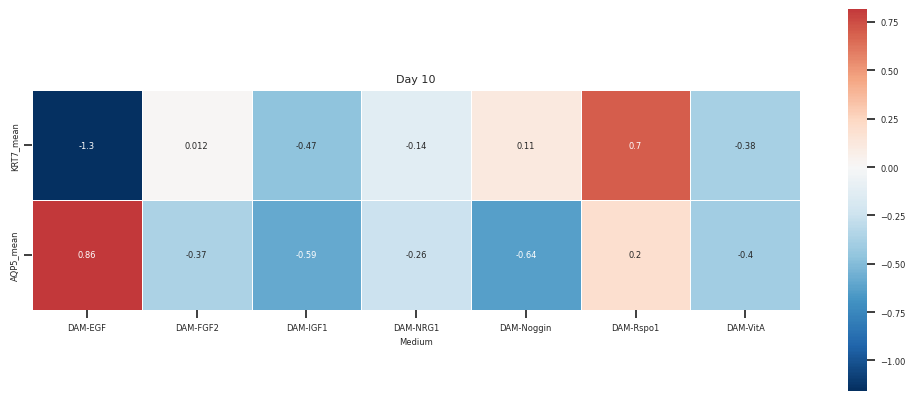

In [19]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 4))
plt.title("Day 10")
        


df = pd.concat([ad.to_df(layer = "z_normalized"), ad.obs.astype(str)], axis = 1)

df = df[df.Other == "D10"]


df_hm = df.groupby(["Medium"])[["KRT7_mean","AQP5_mean"]].mean()

#Remove conditions
df_hm.index = df_hm.index.astype(str)
# df_hm = df_hm.drop(["0", "9A", "9B", "9C", "1C", "1B", "2C", "2B","3C", "3B", "4C", "4B","4A", "5C", "5B", "5A", "6B", "6A", "7C", "7A", "7B", "8C", "8B"])
df_hm = df_hm.drop(["DAM", "Jeon-Full", "Jeon-Half"])
#df_hm = df_hm.drop(["DAM"])
#Plot
sns.heatmap(ax = ax,
           data = df_hm.T,
           annot = True,
           square = True,
           cmap='RdBu_r',
           linewidth = 0.5,
           robust = True,
           center = 0
            )

plt.tight_layout()

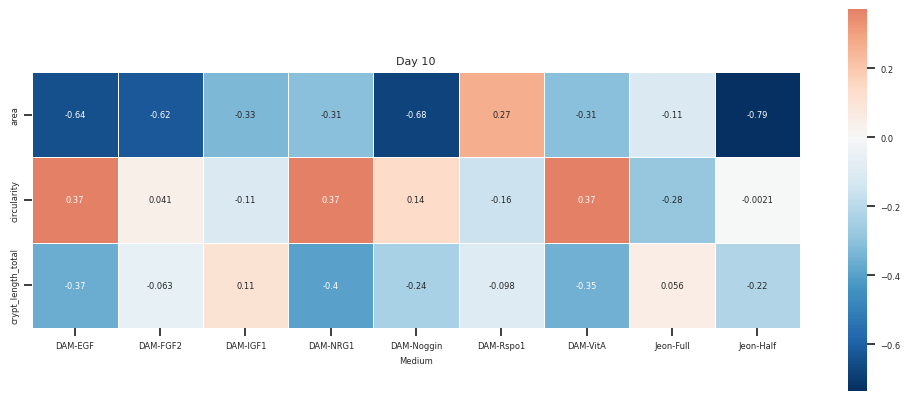

In [23]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 4))
plt.title("Day 10")
        


df = pd.concat([ad.to_df(layer = "z_normalized"), ad.obs.astype(str)], axis = 1)

df = df[df.Other == "D10"]


df_hm = df.groupby(["Medium"])[["area","circularity", "crypt_length_total"]].mean()

#Remove conditions
df_hm.index = df_hm.index.astype(str)
# df_hm = df_hm.drop(["0", "9A", "9B", "9C", "1C", "1B", "2C", "2B","3C", "3B", "4C", "4B","4A", "5C", "5B", "5A", "6B", "6A", "7C", "7A", "7B", "8C", "8B"])
df_hm = df_hm.drop(["DAM"])
#df_hm = df_hm.drop(["DAM"])
#Plot
sns.heatmap(ax = ax,
           data = df_hm.T,
           annot = True,
           square = True,
           cmap='RdBu_r',
           linewidth = 0.5,
           robust = True,
           center = 0
            )

plt.tight_layout()

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'DAM-EGF'),
  Text(1, 0, 'DAM-FGF2'),
  Text(2, 0, 'DAM-IGF1'),
  Text(3, 0, 'DAM-NRG1'),
  Text(4, 0, 'DAM-Noggin'),
  Text(5, 0, 'DAM-Rspo1'),
  Text(6, 0, 'DAM-VitA'),
  Text(7, 0, 'Jeon-Full'),
  Text(8, 0, 'Jeon-Half')])

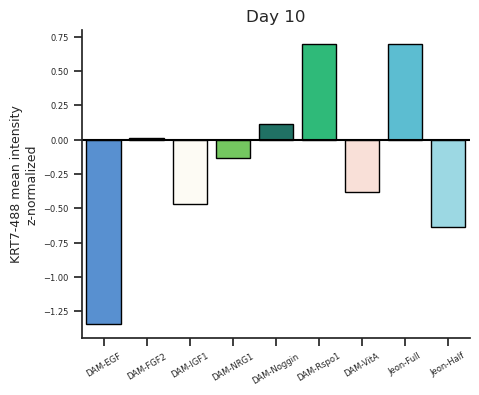

In [17]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 4))
plt.title("Day 10", fontsize = 12)
        


df = pd.concat([ad.to_df(layer = "z_normalized"), ad.obs.astype(str)], axis = 1)

df = df[df.Other == "D10"]

df_hm = df.groupby(["Medium"])[["KRT7_mean","AQP5_mean"]].mean()

#Remove conditions
df_hm.index = df_hm.index.astype(str)

df_hm = df_hm.drop(["DAM"])

sns.barplot(data = df_hm,
            ax = ax,
            x = "Medium",
            y = "KRT7_mean",
            hue = "Medium",
            #order = ["ASCL2", "OLFM4", "ASCL2/OLFM4", "ITLN1", "CD66", "Other", "Negative"],
            palette = palette1,
            edgecolor = "Black",
            linewidth = 1)

plt.axhline(y=0, color='black', linestyle='-')

ax.set_xlabel("")
ax.set_ylabel("KRT7-488 mean intensity\nz-normalized", fontsize = 9)


plt.xticks(rotation=30)

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'DAM-EGF'),
  Text(1, 0, 'DAM-FGF2'),
  Text(2, 0, 'DAM-IGF1'),
  Text(3, 0, 'DAM-NRG1'),
  Text(4, 0, 'DAM-Noggin'),
  Text(5, 0, 'DAM-Rspo1'),
  Text(6, 0, 'DAM-VitA')])

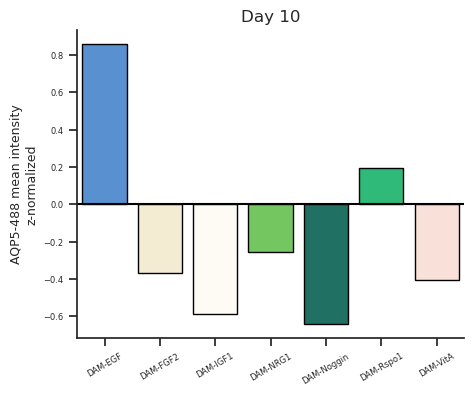

In [20]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 4))
plt.title("Day 10", fontsize = 12)
        


df = pd.concat([ad.to_df(layer = "z_normalized"), ad.obs.astype(str)], axis = 1)

df = df[df.Other == "D10"]

df_hm = df.groupby(["Medium"])[["KRT7_mean","AQP5_mean"]].mean()

#Remove conditions
df_hm.index = df_hm.index.astype(str)

df_hm = df_hm.drop(["DAM", "Jeon-Full", "Jeon-Half"])
#df_hm = df_hm.drop(["DAM"])

sns.barplot(data = df_hm,
            ax = ax,
            x = "Medium",
            y = "AQP5_mean",
            hue = "Medium",
            #order = ["ASCL2", "OLFM4", "ASCL2/OLFM4", "ITLN1", "CD66", "Other", "Negative"],
            palette = palette1,
            edgecolor = "Black",
            linewidth = 1)

plt.axhline(y=0, color='black', linestyle='-')

ax.set_xlabel("")
ax.set_ylabel("AQP5-488 mean intensity\nz-normalized", fontsize = 9)


plt.xticks(rotation=30)

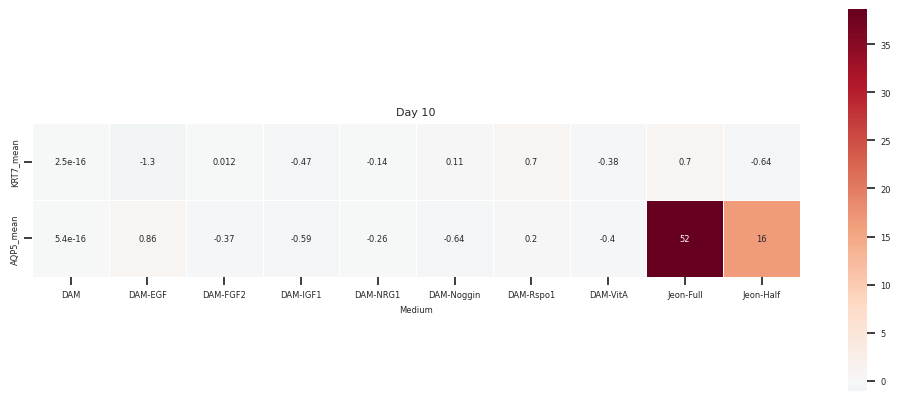

In [31]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 4))
plt.title("Day 10")
        


df = pd.concat([ad.to_df(layer = "z_normalized"), ad.obs.astype(str)], axis = 1)

df = df[df.Other == "D10"]


df_hm = df.groupby(["Medium"])[["KRT7_mean","AQP5_mean"]].mean()

#Remove conditions
df_hm.index = df_hm.index.astype(str)
# df_hm = df_hm.drop(["0", "9A", "9B", "9C", "1C", "1B", "2C", "2B","3C", "3B", "4C", "4B","4A", "5C", "5B", "5A", "6B", "6A", "7C", "7A", "7B", "8C", "8B"])
#df_hm = df_hm.drop(["Ctrl", "Gefitinib"])
#Plot
sns.heatmap(ax = ax,
           data = df_hm.T,
           annot = True,
           square = True,
           cmap='RdBu_r',
           linewidth = 0.5,
           robust = True,
           center = 0
            )

plt.tight_layout()

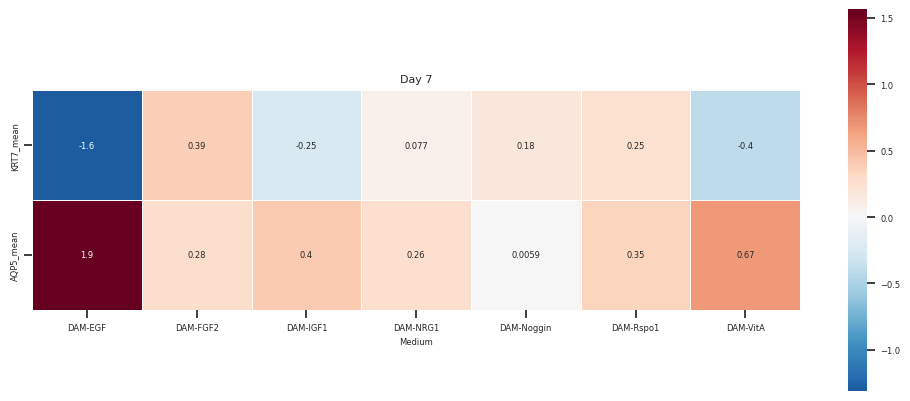

In [33]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 4))
plt.title("Day 7")
        


df = pd.concat([ad.to_df(layer = "z_normalized"), ad.obs.astype(str)], axis = 1)

df = df[df.Other == "D7"]


df_hm = df.groupby(["Medium"])[["KRT7_mean","AQP5_mean"]].mean()

#Remove conditions
df_hm.index = df_hm.index.astype(str)
# df_hm = df_hm.drop(["0", "9A", "9B", "9C", "1C", "1B", "2C", "2B","3C", "3B", "4C", "4B","4A", "5C", "5B", "5A", "6B", "6A", "7C", "7A", "7B", "8C", "8B"])
df_hm = df_hm.drop(["DAM", "Jeon-Full", "Jeon-Half"])
#Plot
sns.heatmap(ax = ax,
           data = df_hm.T,
           annot = True,
           square = True,
           cmap='RdBu_r',
           linewidth = 0.5,
           robust = True,
           center = 0
            )

plt.tight_layout()

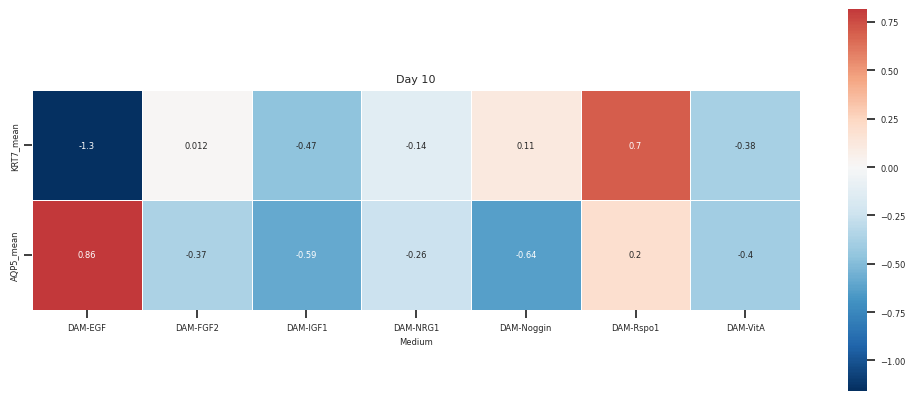

In [34]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 4))
plt.title("Day 10")
        


df = pd.concat([ad.to_df(layer = "z_normalized"), ad.obs.astype(str)], axis = 1)

df = df[df.Other == "D10"]


df_hm = df.groupby(["Medium"])[["KRT7_mean","AQP5_mean"]].mean()

#Remove conditions
df_hm.index = df_hm.index.astype(str)
# df_hm = df_hm.drop(["0", "9A", "9B", "9C", "1C", "1B", "2C", "2B","3C", "3B", "4C", "4B","4A", "5C", "5B", "5A", "6B", "6A", "7C", "7A", "7B", "8C", "8B"])
df_hm = df_hm.drop(["DAM", "Jeon-Full", "Jeon-Half"])
#Plot
sns.heatmap(ax = ax,
           data = df_hm.T,
           annot = True,
           square = True,
           cmap='RdBu_r',
           linewidth = 0.5,
           robust = True,
           center = 0
            )

plt.tight_layout()

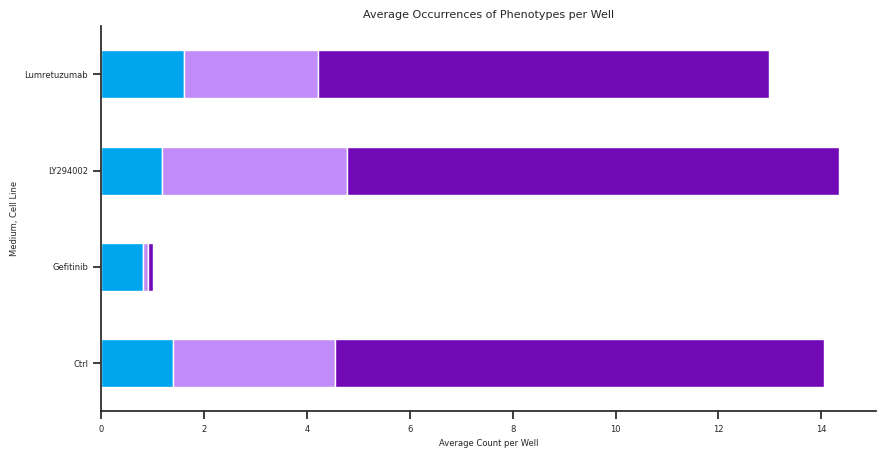

In [107]:
# Combine dataframes
df_int = pd.concat([adEB.to_df(), adEB.obs.astype(str)], axis=1)
df_int["BC-Well"] = df_int.Barcode +"-"+df_int.Well

df = df_int.groupby(["Medium", "BC-Well", "Phenotype"]).size().unstack(fill_value=0).reset_index()

df = df.groupby(["Medium"])[["Round", "Bulging", "Budding"]].mean()

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
df.plot(ax=ax, kind='barh', stacked=True, color=["#00a6ed", "#c18cf9", "#7209b7"], legend=False)

ax.set_title("Average Occurrences of Phenotypes per Well")
ax.set_xlabel("Average Count per Well")
ax.set_ylabel("Medium, Cell Line")

save_images = 0

if save_images == 1:
    save_fig(fig, plot_dir, "6Plot_Phenotype_Comparison_PerWell_all")

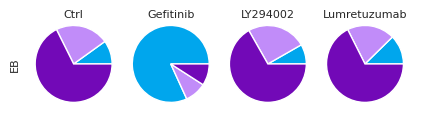

In [114]:
# Prepare data
df_int = pd.concat([adEB.to_df(layer="robust_scaled"), adEB.obs.astype(str)], axis=1)

# Group data
grouped_data = df_int.groupby(["Cell_line","Medium", "Phenotype"]).size().unstack(fill_value=0)

# Get unique values and sort them naturally
cell_lines = natsorted(adEB.obs.Cell_line.unique())
media = natsorted(adEB.obs.Medium.unique())
phenotypes = ["Round", "Bulging", "Budding"]

# Create plot
fig, axes = plt.subplots(nrows=len(cell_lines), ncols=len(media), figsize=(5, 1.35))

for row, cell_line in enumerate(cell_lines):
    for col, medium in enumerate(media):
        ax = axes[row, col] if len(cell_lines) > 1 else axes[col]
        
        if cell_line in grouped_data.index and medium in grouped_data.loc[cell_line].index:
            values = [grouped_data.loc[(cell_line, medium), phenotype] for phenotype in phenotypes]
            
            if sum(values) > 0:
                ax.pie(values, colors=["#00a6ed", "#c18cf9", "#7209b7"])
            else:
                ax.text(0.5, 0.5, "No data", ha='center', va='center')
        else:
            ax.text(0.5, 0.5, "No data", ha='center', va='center')
        
        ax.set_aspect('equal')
        
        if col == 0:
            ax.set_ylabel(cell_line, fontsize=8)
        ax.set_title(medium, fontsize=8, y=0.9)

# Adjust layout
fig.subplots_adjust(wspace=0.01, hspace=0.01)

save_images = 0

if save_images == 1:
    save_fig(fig, plot_dir, "6Plot_PhenoscapeComp_PieChart")

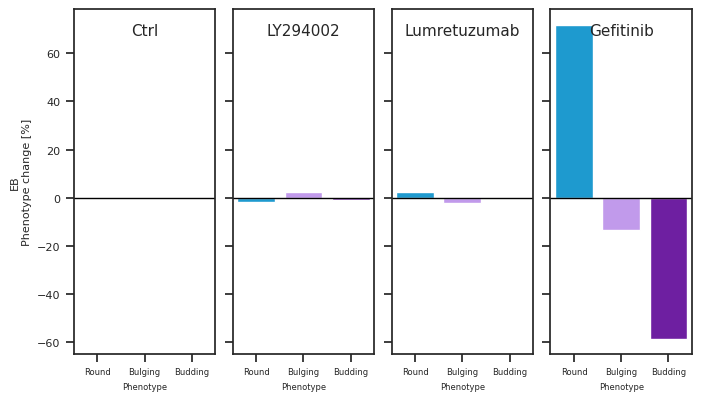

In [121]:
# Calculate % change in Phenotypes
df_int = pd.concat([adEB.to_df(layer="robust_scaled"), adEB.obs.astype(str)], axis=1)

Control = "Ctrl"
phenotypes = ["Round", "Bulging", "Budding"]  # Make sure this is defined

# Group the data
df = df_int.groupby(["Cell_line", "Medium", "Phenotype"]).size().reset_index(name="Numbers")

# Create rows for missing combinations
all_combinations = pd.MultiIndex.from_product([df['Cell_line'].unique(), 
                                               df['Medium'].unique(), 
                                               phenotypes], 
                                              names=['Cell_line', 'Medium', 'Phenotype'])
df = df.set_index(['Cell_line', 'Medium', 'Phenotype']).reindex(all_combinations, fill_value=0).reset_index()

# Calculate totals
df_totals = df.groupby(["Cell_line", "Medium"])["Numbers"].sum().reset_index()

# Merge totals with the main dataframe
df = df.merge(df_totals, on=['Cell_line', 'Medium'], suffixes=('', '_total'))

# Calculate percentages
df['Percentage'] = np.where(df['Numbers_total'] > 0, 
                            (df['Numbers'] / df['Numbers_total']) * 100, 
                            0)

# Calculate percentage change
control_percentages = df[df['Medium'] == Control].set_index(['Cell_line', 'Phenotype'])['Percentage']
df['Ctrl_Diff'] = df.apply(lambda row: row['Percentage'] - control_percentages.get((row['Cell_line'], row['Phenotype']), 0), axis=1)

# Clean up
df = df.drop('Numbers_total', axis=1)

cell_lines = adEB.obs.Cell_line.unique()
media = adEB.obs.Medium.unique()

fig, axes = plt.subplots(nrows=len(cell_lines), ncols=len(media), figsize=(7, 4), sharey=True)

# Prepare data once
df_pivot = df.pivot_table(values='Ctrl_Diff', index=['Cell_line', 'Medium'], columns='Phenotype', fill_value=0)

# Define a function to format axes
def format_axis(ax, show_ylabel=False, ylabel="", title=""):
    ax.axhline(0, color="Black", linewidth=1)
    #ax.set_xticklabels([])
    #ax.set_yticklabels([])
    for spine in ax.spines.values():
        spine.set_visible(True)
    if show_ylabel:
        ax.set_ylabel(ylabel, fontsize=8)
        ax.yaxis.set_tick_params(labelsize=8)
        ax.yaxis.set_visible(True)
    ax.set_title(title, fontsize=11, y=0.90)

# Plot
for cell_line in cell_lines:
    for col, medium in enumerate(media):
        ax = axes[col]
        
        data = df_pivot.loc[(cell_line, medium), phenotypes].reset_index()
        data['Phenotype'] = phenotypes
        data = data.reset_index()
        sns.barplot(ax=ax, data=data, x='Phenotype', y=data[cell_line][medium], hue='Phenotype',
                    order=phenotypes, palette=["#00a6ed", "#c18cf9", "#7209b7"], legend=False)
        
        format_axis(ax, 
                    show_ylabel=(col == 0),
                    ylabel=f"{cell_line}\nPhenotype change [%]" if col == 0 else "",
                    title=medium)
plt.tight_layout()

save_images = 0

if save_images == 1:
    save_fig(fig, plot_dir, "6Plot_Phenotypes_StackedBarplot")

# EBBA

<Axes: ylabel='Medium'>

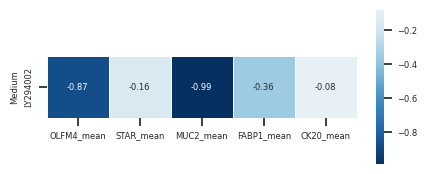

In [5]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,2))


df = pd.concat([adEBBA.to_df(layer = "robust_scaled"), adEBBA.obs.astype(str)], axis = 1)


df_hm = df.groupby(["Medium"])[["OLFM4_mean","STAR_mean", "MUC2_mean", "FABP1_mean", "CK20_mean"]].mean()

#Remove conditions
df_hm.index = df_hm.index.astype(str)
# df_hm = df_hm.drop(["0", "9A", "9B", "9C", "1C", "1B", "2C", "2B","3C", "3B", "4C", "4B","4A", "5C", "5B", "5A", "6B", "6A", "7C", "7A", "7B", "8C", "8B"])
df_hm = df_hm.drop(["Ctrl", "Start", "Gefitinib"])

#Plot
sns.heatmap(ax = ax,
           data = df_hm,
           annot = True,
           square = True,
           cmap='RdBu_r',
           linewidth = 0.5,
           robust = False,
           center = 0
            )

In [7]:
df[(df.Medium == "Ctrl") | (df.Medium == "LY294002")]

,area,area_bbox,area_convex,axis_major_length,axis_minor_length,centroid-0,centroid-1,eccentricity,equivalent_diameter_area,extent,...,ABs,Cell_line,Other,PATH,Staining_Ch1,Staining_Ch2,Staining_Ch3,Staining_Ch4,Phenograph,Phenotype
EBBA1-B06-0,-0.826118,-0.817375,-0.822004,-0.626242,-0.540432,-0.527743,-0.657536,-0.647540,-0.824682,0.399899,...,AB4,EBBA,D12,/tungstenfs/scratch/gliberal/Users/kahnmaur/1_...,DAPI,OLFM4,STAR,MUC2,2,Round
EBBA1-B06-1,1.112538,0.929770,1.025385,1.198805,2.029276,1.607941,1.263782,-0.483696,1.115155,0.045852,...,AB4,EBBA,D12,/tungstenfs/scratch/gliberal/Users/kahnmaur/1_...,DAPI,OLFM4,STAR,MUC2,6,Bloating
EBBA1-B06-2,-1.253485,-1.222269,-1.216746,-0.767087,-0.785903,-0.641479,-0.908763,-0.305351,-1.249420,0.634773,...,AB4,EBBA,D12,/tungstenfs/scratch/gliberal/Users/kahnmaur/1_...,DAPI,OLFM4,STAR,MUC2,2,Round
EBBA1-B06-3,0.245462,0.223239,0.197889,0.257244,0.225570,0.123143,0.177000,0.370823,0.245695,-0.306082,...,AB4,EBBA,D12,/tungstenfs/scratch/gliberal/Users/kahnmaur/1_...,DAPI,OLFM4,STAR,MUC2,0,Budding
EBBA1-B06-4,0.366438,0.210857,0.278633,0.154422,0.579333,0.355937,0.162428,-0.584472,0.366870,0.523990,...,AB4,EBBA,D12,/tungstenfs/scratch/gliberal/Users/kahnmaur/1_...,DAPI,OLFM4,STAR,MUC2,5,Bloating
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
EBBA4-G07-5,-0.025301,-0.133149,-0.072742,-0.284073,0.140084,-0.082969,0.066609,-0.354052,-0.025306,0.126390,...,AB6,EBBA,D12,/tungstenfs/scratch/gliberal/Users/kahnmaur/1_...,DAPI,OLFM4,STAR,FABP1,5,Bloating
EBBA4-G10-0,-0.705962,-0.723639,-0.677297,-0.722591,-0.320201,-0.438516,-0.438295,-1.177651,-0.704884,0.437209,...,AB6,EBBA,D12,/tungstenfs/scratch/gliberal/Users/kahnmaur/1_...,DAPI,OLFM4,STAR,FABP1,2,Round
EBBA4-G10-1,0.017603,-0.017950,0.000000,0.026574,-0.090047,-0.114647,0.122095,0.558506,0.017608,-0.384669,...,AB6,EBBA,D12,/tungstenfs/scratch/gliberal/Users/kahnmaur/1_...,DAPI,OLFM4,STAR,FABP1,1,Bulging
EBBA4-G11-0,-0.797162,-0.819068,-0.759135,-0.744702,-0.404778,-0.485049,-0.574531,-0.777423,-0.795729,0.601574,...,AB6,EBBA,D12,/tungstenfs/scratch/gliberal/Users/kahnmaur/1_...,DAPI,OLFM4,STAR,FABP1,2,Round


Saved as:
/tungstenfs/scratch/gliberal/Users/kahnmaur/2_Analysis/1_Microscopy/0_Main/005-64_ERBBi5/3_Plots/5Plot_Markers_area_T_ratio.pdf
and
/tungstenfs/scratch/gliberal/Users/kahnmaur/2_Analysis/1_Microscopy/0_Main/005-64_ERBBi5/3_Plots/5Plot_Markers_area_T_ratio.png


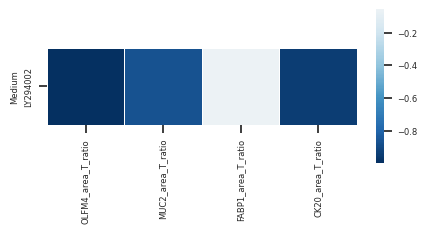

In [12]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,2))


df = pd.concat([adEBBA.to_df(layer = "z_normalized"), adEBBA.obs.astype(str)], axis = 1)


df_hm = df.groupby(["Medium"])[["OLFM4_area_T_ratio", "MUC2_area_T_ratio", "FABP1_area_T_ratio", "CK20_area_T_ratio"]].median()

#Remove conditions
df_hm.index = df_hm.index.astype(str)
# df_hm = df_hm.drop(["0", "9A", "9B", "9C", "1C", "1B", "2C", "2B","3C", "3B", "4C", "4B","4A", "5C", "5B", "5A", "6B", "6A", "7C", "7A", "7B", "8C", "8B"])
df_hm = df_hm.drop(["Ctrl", "Start", "Gefitinib"])

#Plot
sns.heatmap(ax = ax,
           data = df_hm,
           annot = False,
           square = True,
           cmap='RdBu_r',
           linewidth = 0.5,
           robust = False,
           center = 0
            )

save_images = 1

if save_images == 1:
    save_fig(fig, plot_save_dir, "5Plot_Markers_area_T_ratio")

<Axes: ylabel='Medium'>

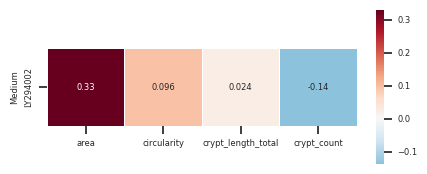

In [7]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,2))


df = pd.concat([adEBBA.to_df(layer = "robust_scaled"), adEBBA.obs.astype(str)], axis = 1)


df_hm = df.groupby(["Medium"])[["area","circularity", "crypt_length_total", "crypt_count"]].mean()

#Remove conditions
df_hm.index = df_hm.index.astype(str)
# df_hm = df_hm.drop(["0", "9A", "9B", "9C", "1C", "1B", "2C", "2B","3C", "3B", "4C", "4B","4A", "5C", "5B", "5A", "6B", "6A", "7C", "7A", "7B", "8C", "8B"])
df_hm = df_hm.drop(["Ctrl", "Start", "Gefitinib"])

#Plot
sns.heatmap(ax = ax,
           data = df_hm,
           annot = True,
           square = True,
           cmap='RdBu_r',
           linewidth = 0.5,
           robust = False,
           center = 0
            )

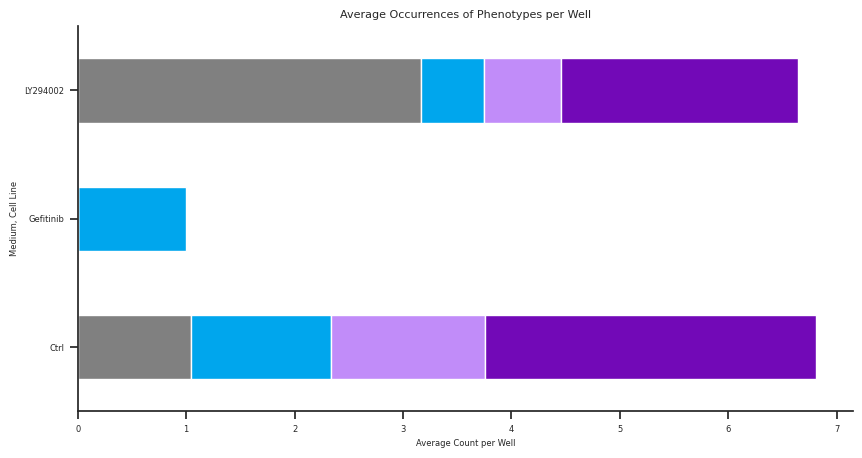

In [133]:
# Combine dataframes
df_int = pd.concat([adEBBA.to_df(), adEBBA.obs.astype(str)], axis=1)
df_int["BC-Well"] = df_int.Barcode +"-"+df_int.Well

df = df_int.groupby(["Medium", "BC-Well", "Phenotype"]).size().unstack(fill_value=0).reset_index()

df = df.groupby(["Medium"])[["Bloating","Round", "Bulging", "Budding"]].mean()

df = df.drop(["Start"])
# Plot
fig, ax = plt.subplots(figsize=(10, 5))
df.plot(ax=ax, kind='barh', stacked=True, color=["Gray","#00a6ed", "#c18cf9", "#7209b7"], legend=False)

ax.set_title("Average Occurrences of Phenotypes per Well")
ax.set_xlabel("Average Count per Well")
ax.set_ylabel("Medium, Cell Line")

save_images = 0

if save_images == 1:
    save_fig(fig, plot_dir, "6Plot_Phenotype_Comparison_PerWell_all")

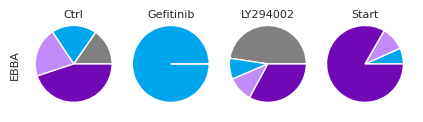

In [135]:
# Prepare data
df_int = pd.concat([adEBBA.to_df(layer="robust_scaled"), adEBBA.obs.astype(str)], axis=1)

# Group data
grouped_data = df_int.groupby(["Cell_line","Medium", "Phenotype"]).size().unstack(fill_value=0)

# Get unique values and sort them naturally
cell_lines = natsorted(adEBBA.obs.Cell_line.unique())
media = natsorted(adEBBA.obs.Medium.unique())
phenotypes = ["Bloating", "Round", "Bulging", "Budding"]

# Create plot
fig, axes = plt.subplots(nrows=len(cell_lines), ncols=len(media), figsize=(5, 1.35))

for row, cell_line in enumerate(cell_lines):
    for col, medium in enumerate(media):
        ax = axes[row, col] if len(cell_lines) > 1 else axes[col]
        
        if cell_line in grouped_data.index and medium in grouped_data.loc[cell_line].index:
            values = [grouped_data.loc[(cell_line, medium), phenotype] for phenotype in phenotypes]
            
            if sum(values) > 0:
                ax.pie(values, colors=["Gray" ,"#00a6ed", "#c18cf9", "#7209b7"])
            else:
                ax.text(0.5, 0.5, "No data", ha='center', va='center')
        else:
            ax.text(0.5, 0.5, "No data", ha='center', va='center')
        
        ax.set_aspect('equal')
        
        if col == 0:
            ax.set_ylabel(cell_line, fontsize=8)
        ax.set_title(medium, fontsize=8, y=0.9)

# Adjust layout
fig.subplots_adjust(wspace=0.01, hspace=0.01)

save_images = 0

if save_images == 1:
    save_fig(fig, plot_dir, "6Plot_PhenoscapeComp_PieChart")

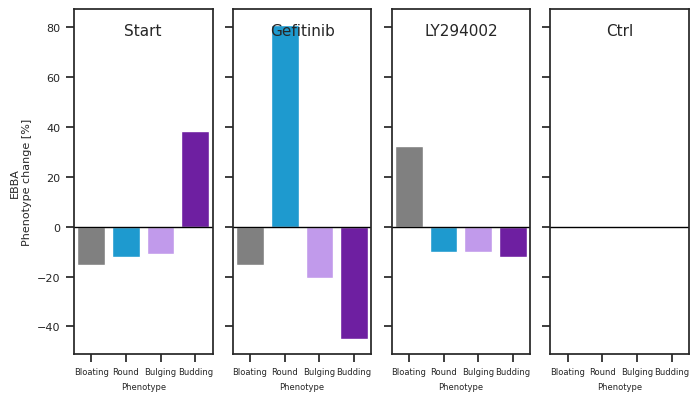

In [138]:
# Calculate % change in Phenotypes
df_int = pd.concat([adEBBA.to_df(layer="robust_scaled"), adEBBA.obs.astype(str)], axis=1)

Control = "Ctrl"
phenotypes = ["Bloating", "Round", "Bulging", "Budding"]  # Make sure this is defined

# Group the data
df = df_int.groupby(["Cell_line", "Medium", "Phenotype"]).size().reset_index(name="Numbers")

# Create rows for missing combinations
all_combinations = pd.MultiIndex.from_product([df['Cell_line'].unique(), 
                                               df['Medium'].unique(), 
                                               phenotypes], 
                                              names=['Cell_line', 'Medium', 'Phenotype'])
df = df.set_index(['Cell_line', 'Medium', 'Phenotype']).reindex(all_combinations, fill_value=0).reset_index()

# Calculate totals
df_totals = df.groupby(["Cell_line", "Medium"])["Numbers"].sum().reset_index()

# Merge totals with the main dataframe
df = df.merge(df_totals, on=['Cell_line', 'Medium'], suffixes=('', '_total'))

# Calculate percentages
df['Percentage'] = np.where(df['Numbers_total'] > 0, 
                            (df['Numbers'] / df['Numbers_total']) * 100, 
                            0)

# Calculate percentage change
control_percentages = df[df['Medium'] == Control].set_index(['Cell_line', 'Phenotype'])['Percentage']
df['Ctrl_Diff'] = df.apply(lambda row: row['Percentage'] - control_percentages.get((row['Cell_line'], row['Phenotype']), 0), axis=1)

# Clean up
df = df.drop('Numbers_total', axis=1)

cell_lines = adEBBA.obs.Cell_line.unique()
media = adEBBA.obs.Medium.unique()

fig, axes = plt.subplots(nrows=len(cell_lines), ncols=len(media), figsize=(7, 4), sharey=True)

# Prepare data once
df_pivot = df.pivot_table(values='Ctrl_Diff', index=['Cell_line', 'Medium'], columns='Phenotype', fill_value=0)

# Define a function to format axes
def format_axis(ax, show_ylabel=False, ylabel="", title=""):
    ax.axhline(0, color="Black", linewidth=1)
    #ax.set_xticklabels([])
    #ax.set_yticklabels([])
    for spine in ax.spines.values():
        spine.set_visible(True)
    if show_ylabel:
        ax.set_ylabel(ylabel, fontsize=8)
        ax.yaxis.set_tick_params(labelsize=8)
        ax.yaxis.set_visible(True)
    ax.set_title(title, fontsize=11, y=0.90)

# Plot
for cell_line in cell_lines:
    for col, medium in enumerate(media):
        ax = axes[col]
        
        data = df_pivot.loc[(cell_line, medium), phenotypes].reset_index()
        data['Phenotype'] = phenotypes
        data = data.reset_index()
        sns.barplot(ax=ax, data=data, x='Phenotype', y=data[cell_line][medium], hue='Phenotype',
                    order=phenotypes, palette=["Gray", "#00a6ed", "#c18cf9", "#7209b7"], legend=False)
        
        format_axis(ax, 
                    show_ylabel=(col == 0),
                    ylabel=f"{cell_line}\nPhenotype change [%]" if col == 0 else "",
                    title=medium)
plt.tight_layout()

save_images = 0

if save_images == 1:
    save_fig(fig, plot_dir, "6Plot_Phenotypes_StackedBarplot")